# Buscar imágenes por su contenido: el germen de la búsqueda multimodal

**Facsímil 11 · IA multimodal y percepción** — capítulos 3 y 4
(CLIP y aprendizaje contrastivo; modelos visión-lenguaje).

La búsqueda multimodal —buscar imágenes con texto, o imágenes parecidas entre sí— se reduce a una idea
sorprendentemente simple: **convertir todo en vectores y medir distancias**. En este cuaderno montas un
buscador de imágenes que no mira nombres de archivo ni etiquetas, sino el **contenido**: conviertes cada
imagen en un **vector descriptor** (un resumen numérico de sus colores) y buscas las más parecidas a una
consulta midiendo distancias entre vectores. Es, en pequeño y simplificado, lo que hace CLIP cuando busca
«un perro en la nieve». Aquí usamos el color para que se vea la mecánica; CLIP usa vectores **aprendidos**
mucho más ricos, pero la idea es **idéntica**.

### Qué vas a aprender
- Que buscar por contenido es **convertir cada imagen en un vector** y comparar distancias.
- Qué es un **descriptor** y cómo un histograma de color resume el «aspecto» de una imagen.
- A medir parecido con la **similitud del coseno** y a ordenar resultados.
- La **limitación** de describir solo por color, y por qué CLIP necesita vectores aprendidos.

### Cuánto cuesta
Unos 12 minutos. CPU, sin claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

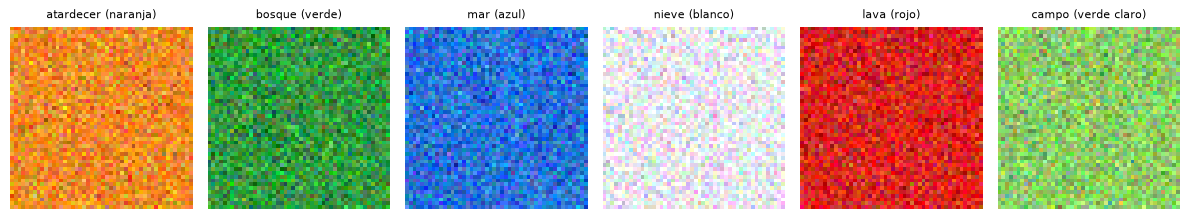

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2)

# Coleccion de imagenes con un color dominante y textura (ruido).
def imagen(color, ruido=0.12):
    base = np.ones((48,48,3)) * np.array(color)
    return np.clip(base + np.random.normal(0, ruido, (48,48,3)), 0, 1)

COLECCION = {
    "atardecer (naranja)": imagen([0.95, 0.55, 0.15]),
    "bosque (verde)":      imagen([0.20, 0.60, 0.25]),
    "mar (azul)":          imagen([0.15, 0.45, 0.85]),
    "nieve (blanco)":      imagen([0.92, 0.92, 0.95]),
    "lava (rojo)":         imagen([0.85, 0.15, 0.12]),
    "campo (verde claro)": imagen([0.55, 0.80, 0.40]),
}
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for ax, (nombre, im) in zip(axes, COLECCION.items()):
    ax.imshow(im); ax.set_title(nombre, fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()


## 1. La idea: todo a vectores, comparar distancias

Un buscador de texto no compara letras: compara *embeddings* (facsímiles 1 y 4). Un buscador de imágenes
hace lo mismo con imágenes. La receta multimodal completa es: pon **imágenes y palabras en el mismo
espacio de vectores**, y entonces «buscar una imagen con la frase *gato en la nieve*» es solo encontrar el
vector de imagen más cercano al vector de esa frase. Aquí daremos el primer paso —imagen a vector— con un
descriptor sencillo, para que la mecánica quede a la vista.


## 2. Convertir cada imagen en un vector: el descriptor de color

El **descriptor**: para cada canal de color (rojo, verde, azul) hacemos un pequeño histograma de cuánto
hay de cada intensidad. Concatenados, dan un vector que resume el «aspecto» de la imagen. Dos imágenes con
colores parecidos tendrán descriptores cercanos. Lo normalizamos para poder compararlos por **ángulo** (la
similitud del coseno), que ignora el brillo global y se fija en la *proporción* de colores.


In [2]:
def descriptor(im, bins=8):
    vec = []
    for canal in range(3):
        h, _ = np.histogram(im[:,:,canal], bins=bins, range=(0,1), density=True)
        vec.append(h)
    v = np.concatenate(vec)
    return v / (np.linalg.norm(v) + 1e-9)      # normalizado, para comparar por angulo (coseno)

VECTORES = {nombre: descriptor(im) for nombre, im in COLECCION.items()}
dim = len(next(iter(VECTORES.values())))
print(f"Cada imagen es ahora un vector de {dim} numeros (3 canales x 8 bins).")
print("Buscar 'parecido' es medir el angulo (coseno) entre estos vectores.")


Cada imagen es ahora un vector de 24 numeros (3 canales x 8 bins).
Buscar 'parecido' es medir el angulo (coseno) entre estos vectores.


## 3. La consulta: «encuéntrame algo como esto»

Creamos una imagen de consulta —un tono anaranjado de atardecer que **no** está en la colección— y
buscamos las más parecidas por **similitud del coseno** entre descriptores. El buscador no sabe nada de
«atardeceres»: solo compara vectores. Aun así, debería traer lo naranja primero y mandar al fondo lo más
lejano en color.


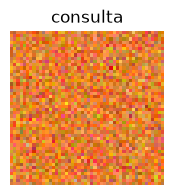

Mas parecidas a la consulta (de mayor a menor similitud):

  atardecer (naranja)    0.969  #######################################
  lava (rojo)            0.689  ############################
  bosque (verde)         0.542  ######################
  nieve (blanco)         0.384  ###############
  mar (azul)             0.269  ###########
  campo (verde claro)    0.263  ###########


In [3]:
consulta = imagen([0.90, 0.50, 0.20])     # un atardecer nuevo, no esta en la coleccion
q = descriptor(consulta)
ranking = sorted(VECTORES.items(), key=lambda kv: -float(q @ kv[1]))   # coseno = producto escalar (ya normalizado)

plt.figure(figsize=(2,2)); plt.imshow(consulta); plt.title("consulta"); plt.axis("off"); plt.show()
print("Mas parecidas a la consulta (de mayor a menor similitud):\n")
for nombre, v in ranking:
    sim = float(q @ v)
    print(f"  {nombre:<22} {sim:.3f}  {'#'*int(round(sim*40))}")


**Lo que ha pasado.** El buscador no entiende de atardeceres ni leyó ninguna etiqueta: convirtió la
consulta en un vector y la comparó con los de la colección. Lo más naranja (el atardecer) sube arriba; lo
más lejano en color (el verde, el azul) cae al fondo. Cambia «histograma de color» por «un vector
aprendido que entiende objetos y escenas» y tienes CLIP: **la misma mecánica**, descriptores muchísimo más
inteligentes.


## 4. La limitación del color (y por qué CLIP es más listo)

Nuestro descriptor solo mira **color**. Eso tiene un límite claro: dos cosas del mismo color pero muy
distintas (un campo verde y una mesa de billar verde) le parecen iguales; y dos fotos del mismo objeto con
luz distinta le parecen diferentes. Lo demostramos: creamos dos imágenes **verdes** (un «bosque» y un
«campo») y vemos que el descriptor las considera casi idénticas, aunque para una persona sean escenas
distintas. Ahí es donde CLIP, con vectores que capturan *qué hay* y no solo *de qué color es*, gana.


In [4]:
verde_bosque = imagen([0.20, 0.55, 0.25])
verde_campo  = imagen([0.30, 0.65, 0.30])
azul_mar     = imagen([0.15, 0.45, 0.85])
db, dc, da = descriptor(verde_bosque), descriptor(verde_campo), descriptor(azul_mar)
print(f"Similitud (color) bosque-campo (ambos verdes): {float(db @ dc):.3f}  <- altisima: 'son lo mismo'")
print(f"Similitud (color) bosque-mar  (verde vs azul): {float(db @ da):.3f}  <- baja: bien")
print("\nEl descriptor de color no distingue dos escenas verdes distintas: ese es su limite.")
print("CLIP usa vectores APRENDIDOS que capturan objetos y escenas, no solo el color dominante.")


Similitud (color) bosque-campo (ambos verdes): 0.883  <- altisima: 'son lo mismo'
Similitud (color) bosque-mar  (verde vs azul): 0.595  <- baja: bien

El descriptor de color no distingue dos escenas verdes distintas: ese es su limite.
CLIP usa vectores APRENDIDOS que capturan objetos y escenas, no solo el color dominante.


## 5. Pruébalo tú

1. **Busca con otra consulta** (un azul de mar, un blanco de nieve). ¿Salen arriba las imágenes correctas?
   El mismo buscador sirve para cualquier consulta sin reentrenar nada.
2. **Sube los `bins`** del histograma (16, 32): descriptor más fino, ¿mejora el orden? Más detalle no
   siempre es mejor.
3. **Añade textura al descriptor:** combina el histograma de color con alguna medida de bordes. ¿Distingue
   ya el bosque del campo?
4. **Imagina el espacio compartido:** si tuvieras vectores de CLIP, podrías buscar estas imágenes
   escribiendo «un atardecer» en texto. Esa es la magia multimodal: texto e imagen en el mismo espacio.


## 6. Errores comunes

- **Confundir buscar por nombre con buscar por contenido.** El primero mira metadatos; el segundo, los
  vectores de la propia imagen.
- **Usar un descriptor pobre para una tarea rica.** El color basta para «encuéntrame algo naranja», pero no
  para «encuéntrame un perro». Para eso, vectores aprendidos (CLIP).
- **Olvidar normalizar los vectores.** Sin normalizar, el coseno se distorsiona y comparas brillo en vez de
  proporción de colores.
- **Creer que CLIP es magia.** Es la misma idea de este cuaderno —imagen a vector, comparar distancias—,
  solo que con un vector aprendido sobre millones de pares imagen-texto.


## 7. Qué te llevas

- Buscar por contenido es **convertir cada imagen en un vector** y medir distancias: el corazón de la
  búsqueda multimodal y de los buscadores de imágenes modernos.
- Aquí el descriptor era el **color**; su límite (no entiende objetos ni escenas) es justo lo que resuelven
  los vectores **aprendidos** de CLIP.
- La idea «todo a vectores, comparar por distancia» es la misma de los *embeddings* de texto (facsímiles 1
  y 4): multimodal es ponerlos a todos en el **mismo espacio**.

**Para seguir:** el capítulo 3 explica cómo CLIP aprende esos vectores alineando texto e imagen; el 6, cómo
se construye un RAG multimodal que recupera páginas, imágenes y tablas con evidencia.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*